<a href="https://colab.research.google.com/github/SofiaFreiman/Lung_epitelium/blob/main/Age_Differences_for_paper_(manuscript_plots_3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scanpy leidenalg scikit-misc adjustText==0.8 gseapy==1.1.3 bbknn
import os
os.kill(os.getpid(), 9)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import os
import pandas as pd
import numpy as np
import scipy.stats
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy
from adjustText import adjust_text
from collections import Counter

sc.settings.verbosity = 1
sns.set(font_scale = 1.2)
sns.set_style("whitegrid")

plt.rcParams['font.family'] = 'Liberation Serif'

In [2]:
!wget https://raw.githubusercontent.com/SofiaFreiman/Lung_epitelium/main/volcano_for_pavan.py
from volcano_for_pavan import volcano

--2025-06-06 06:07:28--  https://raw.githubusercontent.com/SofiaFreiman/Lung_epitelium/main/volcano_for_pavan.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5160 (5.0K) [text/plain]
Saving to: ‘volcano_for_pavan.py’

volcano_for_pavan.p 100%[===================>]   5.04K  --.-KB/s    in 0s      

2025-06-06 06:07:29 (71.2 MB/s) - ‘volcano_for_pavan.py’ saved [5160/5160]



In [3]:
l2_colors = {'Basal cells': 'tab:green', 'Suprabasal cells': 'darkseagreen', 'Goblet cells': 'mediumaquamarine', 'Secretory cells': 'burlywood', 'Ciliated cells': 'mediumpurple', 'Ionocytes': 'orangered', 'Deuterosomal cells': 'deeppink'}
l3_colors = {'Basal cells' : "tab:green", 'Suprabasal cells' : "darkseagreen", "Goblet cells" : "mediumaquamarine", "Secretory cells" : "burlywood", "Multi-ciliated cells 1" : "cornflowerblue", "Multi-ciliated cells 2" : "mediumpurple", "Ionocytes" : "orangered", "Deuterosomal cells" : "deeppink"}

path = "drive/MyDrive/LU/Pavan_data/"

In [4]:
# adata_full - object with all samples

adata_full = sc.read(path + "adata_current.h5ad")
pd.crosstab(adata_full.obs['age_group'], adata_full.obs['sample'])

sample,young-1,aged-1,Sample_21-quant_res,nextseq1.Sample1-quant_res,nextseq3.sample_1-quant_res,nextseq3.sample_2-quant_res,nextseq4.Sample_9-quant_res,young-2,nextseq5.Sample11-quant_res,aged-2
age_group,,,,,,,,,,
young,1719,0,123,32,20,42,9,2284,0,0
aged,0,1692,0,0,0,0,0,0,552,6043


In [5]:
# adata_cut - samples with with the highest number of epitelial cells, use for alternative calculation of DEGs

adata_cut = adata_full[adata_full.obs['sample'].isin(['young-1', 'young-2', 'aged-1', 'aged-2'])].copy()
pd.crosstab(adata_cut.obs['age_group'], adata_cut.obs['sample'])

sample,young-1,aged-1,young-2,aged-2
age_group,,,,
young,1719,0,2284,0
aged,0,1692,0,6043


### Calculate DEGs

In [7]:
anno_col = "anno_l1"
print(set(adata_full.obs[anno_col]))

ct_deg_dict = {}
for cell_type in set(adata_full.obs[anno_col]):
  print(cell_type)
  subset = adata_full[(adata_full.obs[anno_col] == cell_type)]
  sc.pp.filter_genes(subset, min_cells = 10)
  sc.tl.rank_genes_groups(subset, 'age_group', layer = 'lognorm', method='wilcoxon', key_added = "wilcoxon")
  sc.pp.calculate_qc_metrics(subset, percent_top = None, log1p = False, inplace = True)
  tmp_df = sc.get.rank_genes_groups_df(subset, group = 'aged', key='wilcoxon')[['names', 'pvals_adj', 'logfoldchanges', 'scores']]
  tmp_df.set_index("names", inplace = True)
  tmp_df['pct_dropout_by_counts'] = subset.var['pct_dropout_by_counts']
  tmp_df['log2FC_abs'] = abs(tmp_df['logfoldchanges'])
  tmp_df['-logP'] = -np.log(tmp_df.pvals_adj)
  ct_deg_dict[cell_type] = tmp_df
  del subset

{'Deuterosomal cells', 'Basal cells', 'Secretory cells', 'Ionocytes', 'Ciliated cells', 'Goblet cells'}
Deuterosomal cells
Basal cells
Secretory cells
Ionocytes
Ciliated cells
Goblet cells


In [8]:
ct_deg_dict = {k: v for k, v in ct_deg_dict.items() if k not in ['Deuterosomal cells', 'Ionocytes']}
ct_deg_dict.keys()

dict_keys(['Basal cells', 'Secretory cells', 'Ciliated cells', 'Goblet cells'])

In [9]:
ct_deg_dict['Basal cells'][:2]

,pvals_adj,logfoldchanges,scores,pct_dropout_by_counts,log2FC_abs,-logP
names,,,,,,
RPS26,1.025154e-194,1.263585,30.094177,0.596701,1.263585,446.676665
MT-ND4,3.954029e-126,0.541328,24.266256,0.105300,0.541328,288.750987


In [10]:
subset = adata_full[(adata_full.obs['anno_l1'].isin(['Basal cells', 'Ciliated cells', 'Goblet cells', 'Secretory cells']))]
sc.pp.filter_genes(subset, min_cells = 10)
sc.tl.rank_genes_groups(subset, 'age_group', layer = 'lognorm', method='wilcoxon', key_added = "wilcoxon")
sc.pp.calculate_qc_metrics(subset, percent_top = None, log1p = False, inplace = True)
DEGs_age = sc.get.rank_genes_groups_df(subset, group = 'aged', key='wilcoxon')[['names', 'pvals_adj', 'logfoldchanges', 'scores']]
DEGs_age.set_index("names", inplace = True)
DEGs_age['pct_dropout_by_counts'] = subset.var['pct_dropout_by_counts']
DEGs_age['log2FC_abs'] = abs(DEGs_age['logfoldchanges'])
DEGs_age['-logP'] = -np.log(DEGs_age.pvals_adj)
del subset
print(len(DEGs_age))
DEGs_age[:2]

23345


,pvals_adj,logfoldchanges,scores,pct_dropout_by_counts,log2FC_abs,-logP
names,,,,,,
MT-ND4,0.0,0.595527,56.725376,0.088624,0.595527,inf
RPS26,0.0,0.655050,43.845531,1.087657,0.655050,inf


### GSEA

In [11]:
t1 = time.time()
gene_set = ['GO_Biological_Process_2023', 'MSigDB_Hallmark_2020', 'GO_Cellular_Component_2023']
gsea_res = {}

for cell_type in ct_deg_dict:
  print(cell_type)
  df_tmp = ct_deg_dict[cell_type][['scores']]
  df_tmp = df_tmp.sort_values('scores', ascending = False)
  res_tmp = gseapy.prerank(rnk = df_tmp, gene_sets=gene_set, seed = 6, permutation_num = 1000).res2d
  res_tmp['Cell type'] = cell_type
  res_tmp['gene set'] = res_tmp['Term'].str.extract(r'(.*?\d{4})')
  res_tmp['Term_name'] = res_tmp['Term'].str.extract(r'\d{4}__([\s\S]*)')
  res_tmp['Term_name'] = res_tmp.apply(lambda row: f"{row['Term_name']} (HallmarkDB)" if row['gene set'] == 'MSigDB_Hallmark_2020' else row['Term_name'], axis=1)
  gsea_res[cell_type] = res_tmp
  del df_tmp
  del res_tmp
t2 = time.time()
print(round((t2-t1)/60, 1), 'min')

2025-06-06 06:09:51,487 [WARNING] Duplicated values found in preranked stats: 6.75% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Basal cells


2025-06-06 06:11:05,470 [WARNING] Duplicated values found in preranked stats: 7.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Secretory cells


2025-06-06 06:12:07,766 [WARNING] Duplicated values found in preranked stats: 5.20% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Ciliated cells


2025-06-06 06:13:09,857 [WARNING] Duplicated values found in preranked stats: 30.17% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Goblet cells
4.1 min


In [12]:
gsea_res['Basal cells'][:2]

,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes,Cell type,gene set,Term_name
0,prerank,GO_Cellular_Component_2023__Small Ribosomal Su...,0.679209,2.893132,0.0,0.0,0.0,22/38,1.62%,RPS26;RPS11;RPS17;RPS27;RPS18;RPS16;RPS15;RPS2...,Basal cells,GO_Cellular_Component_2023,Small Ribosomal Subunit (GO:0015935)
1,prerank,GO_Cellular_Component_2023__Cytosolic Small Ri...,0.691352,2.850088,0.0,0.0,0.0,22/37,1.62%,RPS26;RPS11;RPS17;RPS27;RPS18;RPS16;RPS15;RPS2...,Basal cells,GO_Cellular_Component_2023,Cytosolic Small Ribosomal Subunit (GO:0022627)


In [13]:
# Remove Deuterosomal and Ionocyte
print(gsea_res.keys())
gsea_res = {k: v for k, v in gsea_res.items() if k not in ['Deuterosomal cells', 'Ionocytes']}
print(gsea_res.keys())

dict_keys(['Basal cells', 'Secretory cells', 'Ciliated cells', 'Goblet cells'])
dict_keys(['Basal cells', 'Secretory cells', 'Ciliated cells', 'Goblet cells'])


In [14]:
db_ls = ["GO_Biological_Process_2023", 'GO_Molecular_Function_2023', 'MSigDB_Hallmark_2020', 'GO_Cellular_Component_2023']
db = db_ls[2]
print(db)

db_dict = {}
for cell_type, data in gsea_res.items():
  tmp = data[data['gene set'] == db].copy()
  tmp = tmp[tmp['FDR q-val'] < 0.05]
  db_dict[cell_type] = tmp['Term_name'].to_list()

# Find pathways signifcantly changed in at least N cell types
N=2
all_terms = [term for terms in db_dict.values() for term in terms] # Flatten the lists of Term_name from all cell types
term_counts = Counter(all_terms) # Count the occurrences of each Term_name
terms_in_at_least_N = [term for term, count in term_counts.items() if count >= N]
print(f"Terms appearing in at least {N} cell types:")
print(len(terms_in_at_least_N))
print(terms_in_at_least_N)

MSigDB_Hallmark_2020
Terms appearing in at least 2 cell types:
4
['TNF-alpha Signaling via NF-kB (HallmarkDB)', 'Hypoxia (HallmarkDB)', 'Oxidative Phosphorylation (HallmarkDB)', 'Myc Targets V1 (HallmarkDB)']


In [15]:
# Final list of terms
terms = ['Small Ribosomal Subunit (GO:0015935)', 'Large Ribosomal Subunit (GO:0015934)',
    'Cytoplasmic Translation (GO:0002181)', 'Response To Fibroblast Growth Factor (GO:0071774)',
         'Positive Regulation Of miRNA Metabolic Process (GO:2000630)',
         'Response To Glucocorticoid (GO:0051384)', 'Antimicrobial Humoral Immune Response Mediated By Antimicrobial Peptide (GO:0061844)',
         'Mitochondrial Translation (GO:0032543)',
         'TNF-alpha Signaling via NF-kB (HallmarkDB)', 'Oxidative Phosphorylation (HallmarkDB)', 'Myc Targets V1 (HallmarkDB)',]

Text(0.5, 0, '')

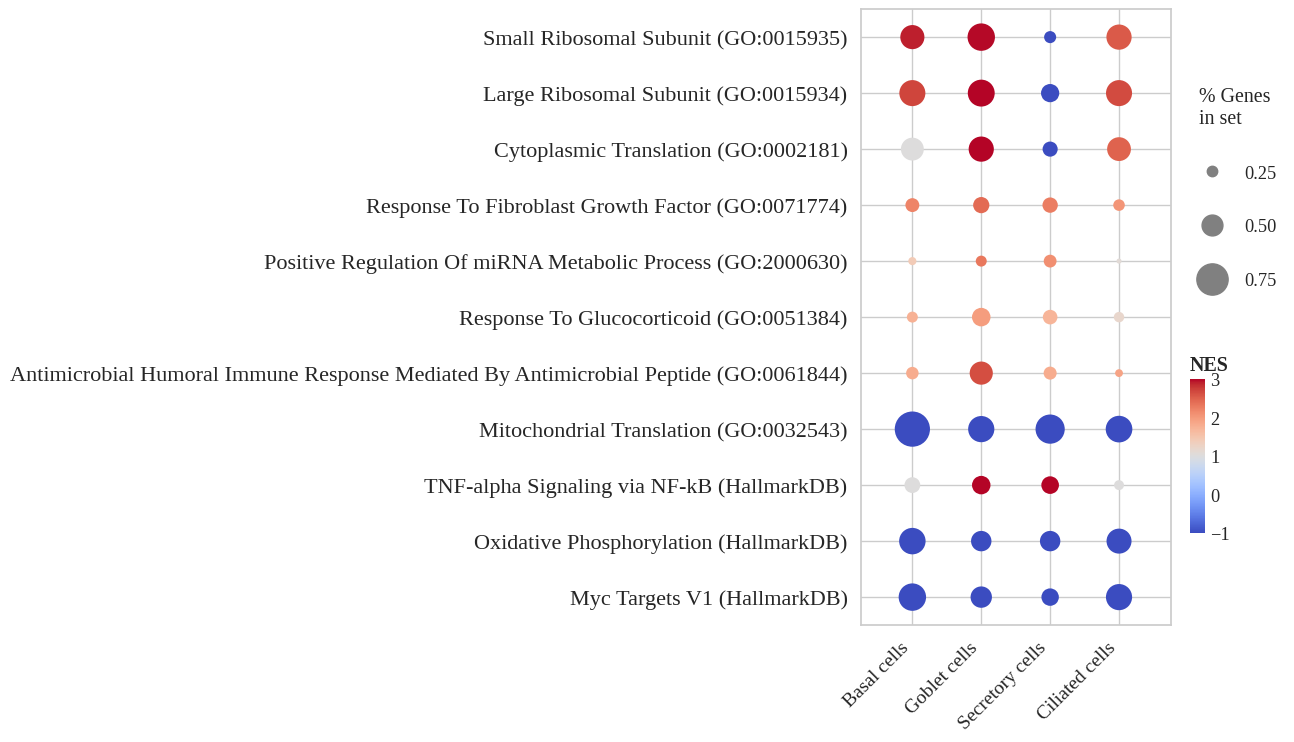

In [16]:
order_terms = terms.copy()
order_terms.reverse()

res_df = pd.concat(gsea_res.values())
res_df.reset_index(inplace = True)
res_df['Cell type'] = res_df['Cell type'].astype('category')
res_df = res_df[res_df['Cell type'].isin(['Basal cells', 'Goblet cells', 'Secretory cells', 'Ciliated cells'])] # 'Ionocytes', 'Deuterosomal cells'
res_df['Cell type'] = res_df['Cell type'].cat.remove_unused_categories()
res_df['Cell type'] = res_df['Cell type'].cat.reorder_categories(['Basal cells', 'Goblet cells', 'Secretory cells', 'Ciliated cells',])
res_df = res_df[res_df["Term_name"].isin(terms)]
res_df.reset_index(inplace = True)

ax = gseapy.dotplot(res_df,
              column="NES",
              x='Cell type',
              y = "Term_name",
              y_order=order_terms,
              size=5,
              top_term=100,
              figsize=(5, 8),
              xticklabels_rot=45,
              show_ring=False,
              marker='o',
              cmap = 'coolwarm',
              )
plt.xlabel('')

### OVA pathway analysis

In [9]:
def DE_figs(df, up_fig=True, down_fig=True, p_val=0.05, logFC=0.1, gene_set='GO_Biological_Process_2023', return_df=False, title = None):
# 'GO_Biological_Process_2023', 'GO_Molecular_Function_2023', 'GO_Cellular_Component_2023', 'KEGG_2021_Human', 'Reactome_2022', 'MSigDB_Hallmark_2020', 'WikiPathway_2023_Human'
  tmp = df.copy()
  tmp = tmp[tmp.pvals_adj < p_val]
  up = tmp[tmp.logfoldchanges > logFC]
  down = tmp[tmp.logfoldchanges < -logFC]
  print(len(tmp), len(up), len(down))
  if len(up) > 0:
    enr_up = gseapy.enrichr(gene_list = up.index.to_list(), gene_sets = gene_set, outdir=None)
  if len(down) > 0:
    enr_down = gseapy.enrichr(gene_list = down.index.to_list(), gene_sets = gene_set, outdir=None)

  if up_fig:
    gseapy.dotplot(enr_up.results, figsize=(3,5), title = title, cmap = plt.cm.autumn_r,)
  if down_fig:
    gseapy.dotplot(enr_down.results, figsize=(3,5), title = title, cmap = plt.cm.winter_r)
  if return_df:
    if return_df=="up":
      return enr_up.res2d
    if return_df=="down":
      return enr_down.res2d
    else:
      print("Values for return_df must be 'up' or 'down'")

In [11]:
## Chosen pathways to display

terms_up = [
    'Cytoplasmic Translation (GO:0002181)', 'Response To Fibroblast Growth Factor (GO:0071774)', ## GO BioProc
    "Regulation Of miRNA Transcription (GO:1902893)", ## GO BioProc
    'Small Ribosomal Subunit (GO:0015935)', 'Large Ribosomal Subunit (GO:0015934)', ## GO CellComp
    'TNF-alpha Signaling via NF-kB (HallmarkDB)', 'Apoptosis (HallmarkDB)', "p53 Pathway (HallmarkDB)", ## Hallmark
    ]

terms_down = [
              'Mitochondrial Translation (GO:0032543)', "Mitochondrion Organization (GO:0007005)", ## GO Biological Processes
              'Intracellular Protein Transport (GO:0006886)', "Cilium Assembly (GO:0060271)", ## GO Biological Processes
              "Myc Targets V1 (HallmarkDB)", ## Hallmark
              "Oxidative Phosphorylation (HallmarkDB)", "mTORC1 Signaling (HallmarkDB)", ## Hallmark
              ]

#### Up-regulated pathways

503 112 365
5565 135 4782
5092 727 3537
6529 151 4120


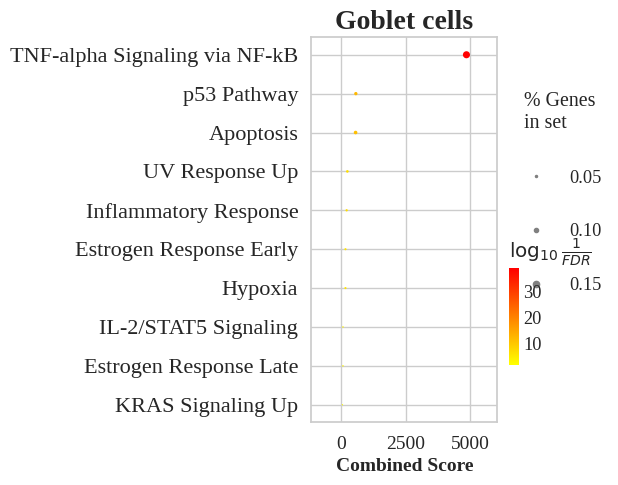

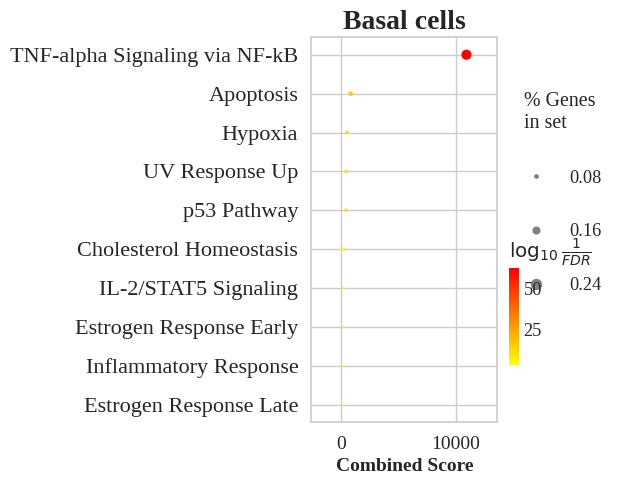

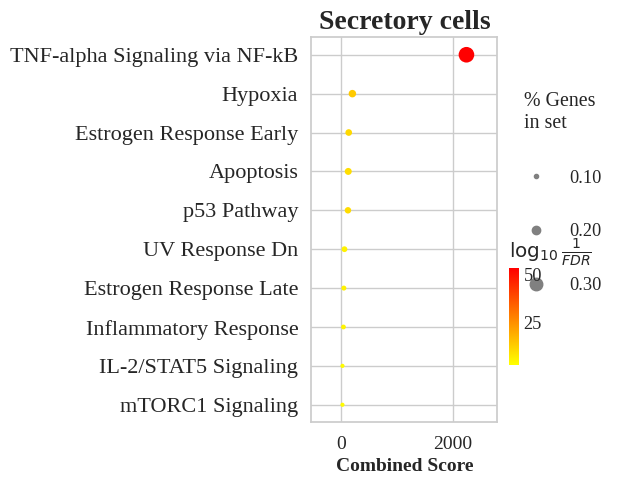

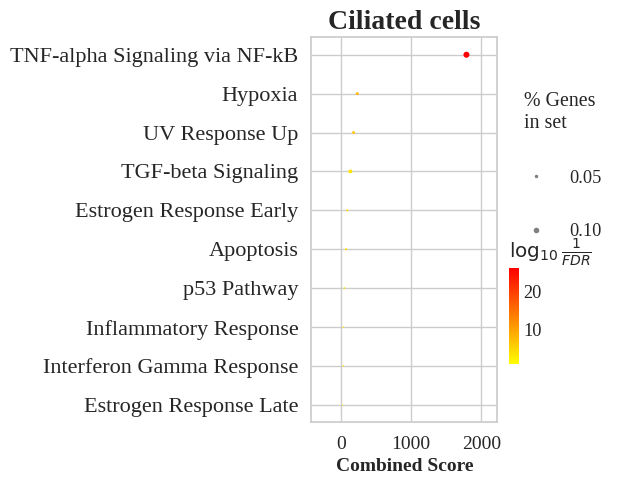

In [21]:
## Enriched pathways for each cell type within chosen database (gene_set parameter)

for ct in ct_deg_dict.keys():
  DE_figs(ct_deg_dict[ct], up_fig=True, down_fig=False, p_val=0.001, logFC=0.25, gene_set = 'MSigDB_Hallmark_2020', return_df=False, title = ct)

In [22]:
# Prepare tables with enriched pathways from GO Biol Proc database

res_GO_BioProc_up = {}
for ct in ct_deg_dict.keys():
  res_GO_BioProc_up[ct] = DE_figs(ct_deg_dict[ct], up_fig=False, down_fig=False, p_val=0.001, logFC=0.25, gene_set = 'GO_Biological_Process_2023', return_df="up")
  res_GO_BioProc_up[ct]['Cell type'] = ct

GO_BioProc_up_df = pd.concat(res_GO_BioProc_up.values())
GO_BioProc_up_df.reset_index(inplace = True)

503 112 365
5565 135 4782
5092 727 3537
6529 151 4120


In [23]:
# Prepare tables with enriched pathways from GO Cellular Comp database

res_GO_CellComp_up = {}
for ct in ct_deg_dict.keys():
  res_GO_CellComp_up[ct] = DE_figs(ct_deg_dict[ct], up_fig=False, down_fig=False, p_val=0.001, logFC=0.25, gene_set = 'GO_Cellular_Component_2023', return_df="up")
  res_GO_CellComp_up[ct]['Cell type'] = ct

GO_CellComp_up_df = pd.concat(res_GO_CellComp_up.values())
GO_CellComp_up_df.reset_index(inplace = True)

503 112 365
5565 135 4782
5092 727 3537
6529 151 4120


In [24]:
# Prepare tables with enriched pathways from Hallmark database

res_Hallmark_up = {}
for ct in ct_deg_dict.keys():
  res_Hallmark_up[ct] = DE_figs(ct_deg_dict[ct], up_fig=False, down_fig=False, p_val=0.001, logFC=0.25, gene_set = 'MSigDB_Hallmark_2020', return_df="up")
  res_Hallmark_up[ct]['Cell type'] = ct
  res_Hallmark_up[ct]["Term"] = res_Hallmark_up[ct]["Term"] + " (HallmarkDB)"

Hallmark_up_df = pd.concat(res_Hallmark_up.values())
Hallmark_up_df.reset_index(inplace = True)

503 112 365
5565 135 4782
5092 727 3537
6529 151 4120


In [31]:
## Combain all up-regulated pathways

df1 = GO_BioProc_up_df[GO_BioProc_up_df.Term.isin(terms_up)]
df2 = GO_CellComp_up_df[GO_CellComp_up_df.Term.isin(terms_up)]
df3 = Hallmark_up_df[Hallmark_up_df.Term.isin(terms_up)]
df = pd.concat([df1, df2, df3])
del df["index"]
df.reset_index(inplace = True)
del df["index"]
df['Cell type'] = df['Cell type'].astype('category')
df['Cell type'] = df['Cell type'].cat.reorder_categories(['Basal cells', 'Goblet cells', 'Secretory cells', 'Ciliated cells'])
print(len(df))
df[:2]

32


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Cell type
0,GO_Biological_Process_2023,Cytoplasmic Translation (GO:0002181),13/93,4.650070e-15,5.142978e-12,0,0,32.513131,1072.994915,RPL21;RPL31;RPS26;RPS17;RPS28;RPS16;RPS27;RPL2...,Goblet cells
1,GO_Biological_Process_2023,Regulation Of miRNA Transcription (GO:1902893),6/59,9.535621e-07,1.054640e-04,0,0,21.183695,293.670867,EGR1;DDX5;JUN;MYC;FOS;KLF4,Goblet cells


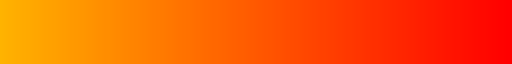

In [32]:
# Cut the cmap to start with brighter color

from matplotlib.colors import LinearSegmentedColormap

def truncate_colormap(cmap, minval=0.3, maxval=1.0, n=100):
    new_cmap = LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

cmap = plt.get_cmap('autumn_r')
new_cmap = truncate_colormap(cmap, 0.3, 1)

new_cmap

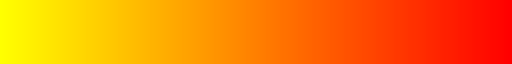

In [33]:
plt.cm.autumn_r

Text(0.5, 0, '')

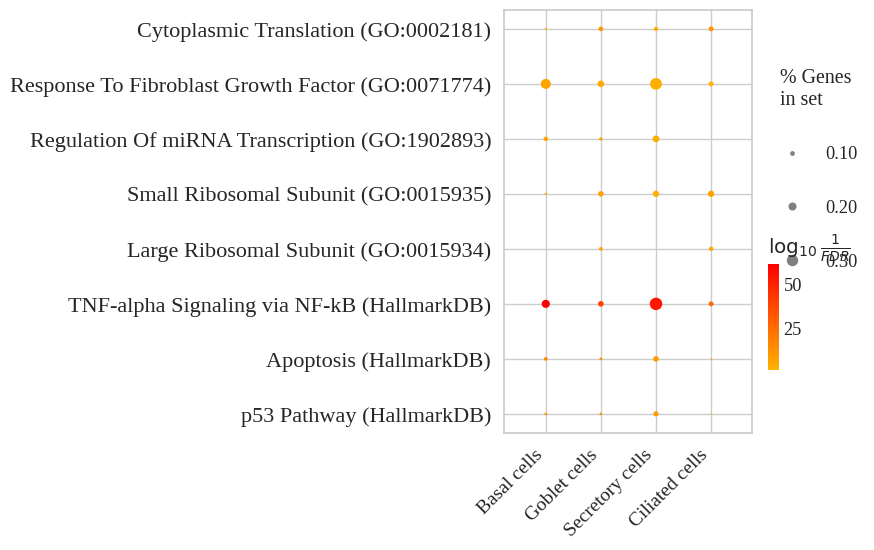

In [35]:
ax = gseapy.dotplot(df,
              column="Adjusted P-value",
              x='Cell type',
              y_order = terms_up[::-1],
              y = "Term",
              size=4,
              top_term=100,
              figsize=(4,5.5),
              # title = "Aged vs Young up-regulated pathways",
              xticklabels_rot=45,
              show_ring=False,
              marker='o',
              cmap = new_cmap,
             )
plt.xlabel('')

#### Down-regulated pathways

503 112 365
5565 135 4782
5092 727 3537
6529 151 4120


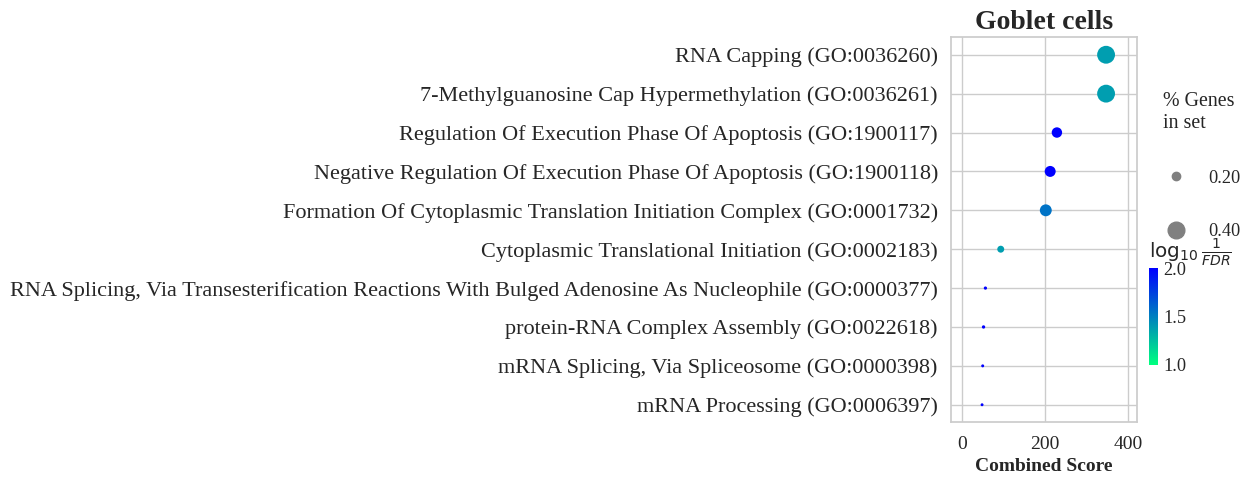

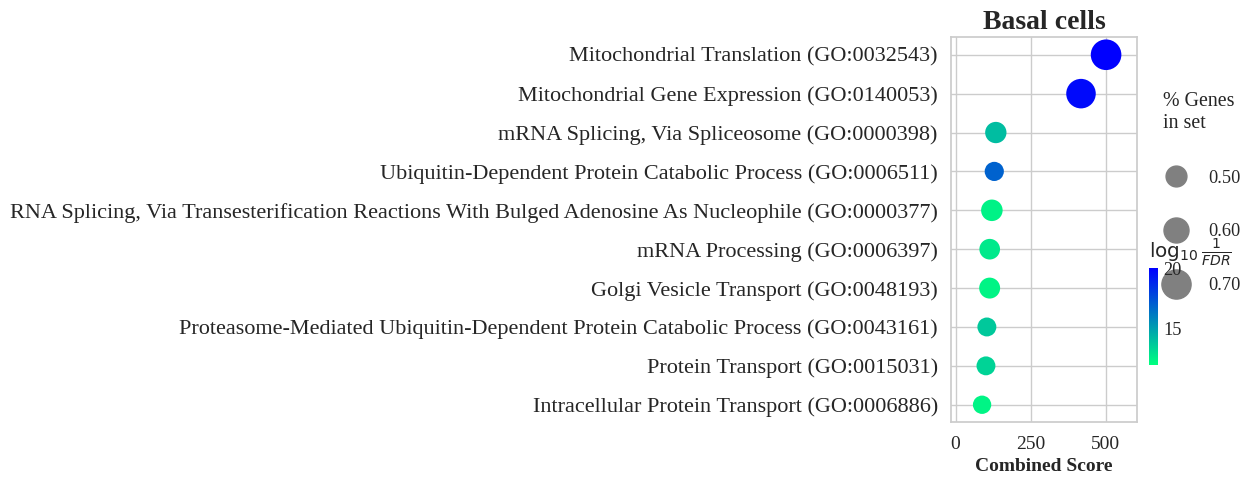

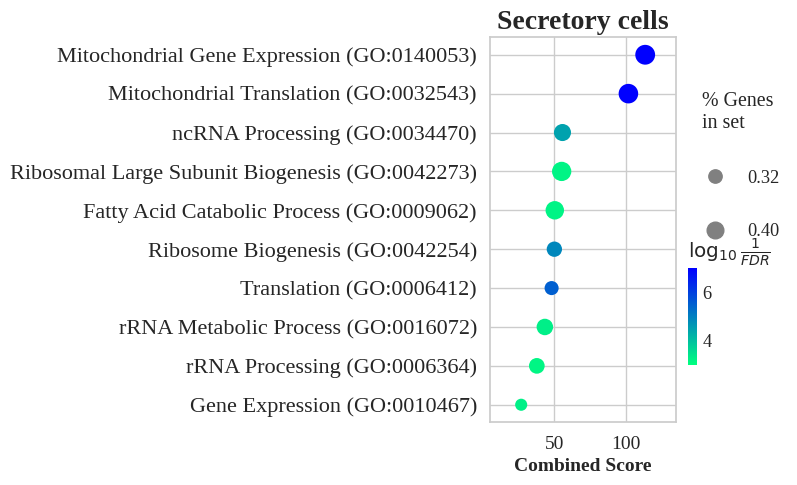

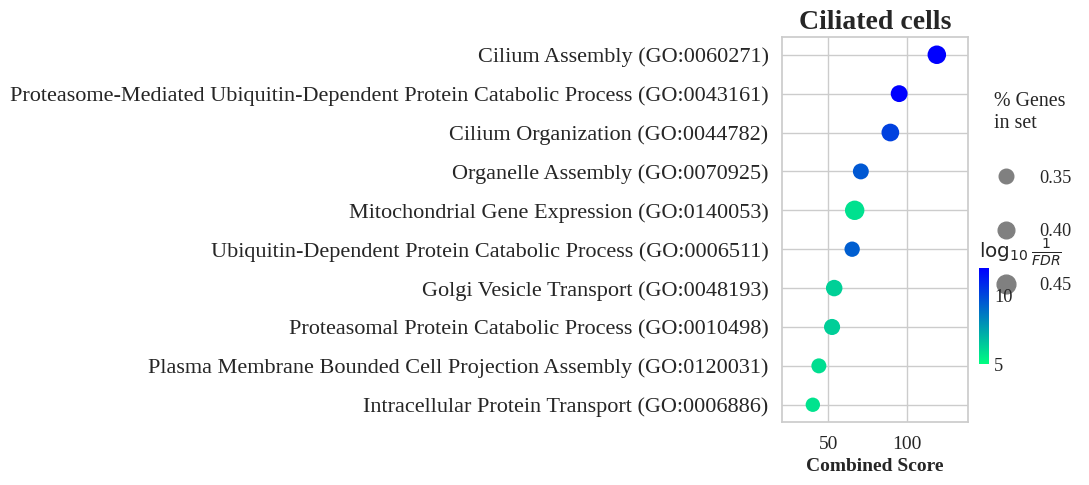

In [36]:
for ct in ct_deg_dict.keys():
  DE_figs(ct_deg_dict[ct], up_fig=False, down_fig=True, p_val=0.001, logFC=0.25, gene_set = 'GO_Biological_Process_2023', return_df=False, title = ct)

In [37]:
res_GO_BioProc_down = {}
for ct in ct_deg_dict.keys():
  res_GO_BioProc_down[ct] = DE_figs(ct_deg_dict[ct], up_fig=False, down_fig=False, p_val=0.001, logFC=0.25, gene_set = 'GO_Biological_Process_2023', return_df="down")
  res_GO_BioProc_down[ct]['Cell type'] = ct

GO_BioProc_down_df = pd.concat(res_GO_BioProc_down.values())
GO_BioProc_down_df.reset_index(inplace = True)

503 112 365
5565 135 4782
5092 727 3537
6529 151 4120


In [38]:
res_GO_CellComp_down = {}
for ct in ct_deg_dict.keys():
  res_GO_CellComp_down[ct] = DE_figs(ct_deg_dict[ct], up_fig=False, down_fig=False, p_val=0.001, logFC=0.25, gene_set = 'GO_Cellular_Component_2023', return_df="down")
  res_GO_CellComp_down[ct]['Cell type'] = ct

GO_CellComp_down_df = pd.concat(res_GO_CellComp_down.values())
GO_CellComp_down_df.reset_index(inplace = True)

503 112 365
5565 135 4782
5092 727 3537
6529 151 4120


In [39]:
res_Hallmark_down = {}
for ct in ct_deg_dict.keys():
  res_Hallmark_down[ct] = DE_figs(ct_deg_dict[ct], up_fig=False, down_fig=False, p_val=0.001, logFC=0.25, gene_set = 'MSigDB_Hallmark_2020', return_df="down")
  res_Hallmark_down[ct]['Cell type'] = ct
  res_Hallmark_down[ct]["Term"] = res_Hallmark_down[ct]["Term"] + " (HallmarkDB)"

Hallmark_down_df = pd.concat(res_Hallmark_down.values())
Hallmark_down_df.reset_index(inplace = True)

503 112 365
5565 135 4782
5092 727 3537
6529 151 4120


In [41]:
df1 = GO_BioProc_down_df[GO_BioProc_down_df.Term.isin(terms_down)]
df2 = GO_CellComp_down_df[GO_CellComp_down_df.Term.isin(terms_down)]
df3 = Hallmark_down_df[Hallmark_down_df.Term.isin(terms_down)]
df = pd.concat([df1, df2, df3])
del df["index"]
df.reset_index(inplace = True)
del df["index"]
df['Cell type'] = df['Cell type'].astype('category')
df['Cell type'] = df['Cell type'].cat.reorder_categories(['Basal cells', 'Goblet cells', 'Secretory cells', 'Ciliated cells'])
print(len(df))
df[:2]

28


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Cell type
0,GO_Biological_Process_2023,Intracellular Protein Transport (GO:0006886),12/325,0.016766,0.250301,0,0,2.098526,8.579643,VPS29;NPM1;TSG101;APEX1;PDCD6;ERP29;ARL1;HIKES...,Goblet cells
1,GO_Biological_Process_2023,Mitochondrial Translation (GO:0032543),4/98,0.104598,0.403560,0,0,2.303413,5.200263,MRPL51;MRPL14;MRPL21;MRPL43,Goblet cells


Text(0.5, 0, '')

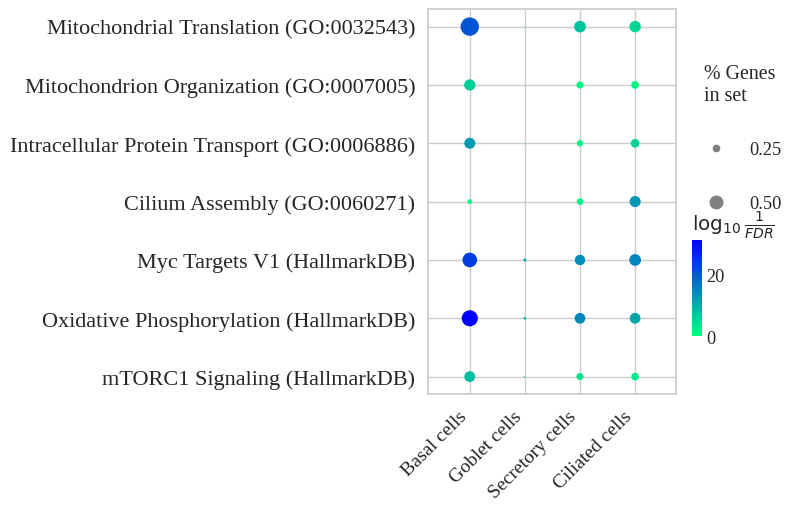

In [44]:
ax = gseapy.dotplot(df,
              column="Adjusted P-value",
              x='Cell type',
              y_order = terms_down[::-1],
              x_order = ['Basal cells', 'Goblet cells', 'Secretory cells', 'Ciliated cells'],
              y = "Term",
              size=3,
              top_term=100,
              figsize=(4,5),
              # title = "Aged vs Young down-regulated pathways",
              xticklabels_rot=45,
              show_ring=False,
              marker='o',
              cmap = plt.cm.winter_r,
              cutoff = 1
             )
plt.xlabel('')

### Mitochondrial Transation vs Cytoplasmic Translation

In [126]:
!ls {path}Age_pathway_analysis

Down_genes.xlsx  Down_pathways.xlsx  Up_genes.xlsx  Up_pathways.xlsx


In [127]:
up_genes = pd.read_excel(path + "Age_pathway_analysis/Up_genes.xlsx", index_col='names')
up_pathways = pd.read_excel(path + "Age_pathway_analysis/Up_pathways.xlsx", index_col = 0)
down_genes = pd.read_excel(path + "Age_pathway_analysis/Down_genes.xlsx", index_col='names')
down_pathways = pd.read_excel(path + "Age_pathway_analysis/Down_pathways.xlsx", index_col = 0)

In [129]:
ct_mt_ribo_genes = []
ct_mt_ribo_genes += down_pathways['Mitochondrial Translation (GO:0032543)'].dropna().to_list()
ct_mt_ribo_genes += up_pathways['Cytoplasmic Translation (GO:0002181)'].dropna().to_list()
ct_mt_ribo_genes += up_pathways['Large Ribosomal Subunit (GO:0015934)'].dropna().to_list()
ct_mt_ribo_genes += up_pathways['Small Ribosomal Subunit (GO:0015935)'].dropna().to_list()
ct_mt_ribo_genes = list(set(ct_mt_ribo_genes))
print(len(ct_mt_ribo_genes))
ct_mt_ribo_genes[:5]

98


['RPL37A', 'MRPS2', 'MRPL11', 'DAP3', 'RPL23A']

In [155]:
mt_ribo_short = ['RPS26', 'RPS11', 'RPS27', 'RPL21', 'RPL37A', 'RPL27A', 'RPL36', 'RPL35',
                 'MRPL23', 'MRPL43', 'MRPS25', 'TSFM', 'MRPL18', 'MRPS6', 'MRPL58', 'MRPS12', 'MRPL50', 'MRPL22']

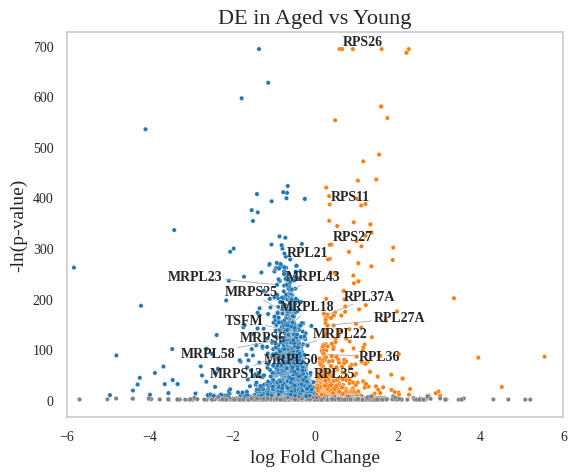

In [156]:
df = DEGs_age.copy()
df = df[df.pvals_adj < 0.90]
volcano(df, title="DE in Aged vs Young", text_pval_cut = 100, xlim = 6, too_crowded = True, genes_of_interest = mt_ribo_short, print_sig_genes = False,
        color_left = "tab:blue", color_right = 'tab:orange', log_method = 'natural')

### Plots

In [46]:
!ls {path}Age_pathway_analysis

Down_genes.xlsx  Down_pathways.xlsx  Up_genes.xlsx  Up_pathways.xlsx


In [144]:
# Selected genes from up- and down-regulated pathways in Aged vs Young comparisson
gene_ls = ['CDKN1A',
           'GADD45B', "BTG2", "JUN", "ATF3", "RHOB", "IRF1", "GPX4", "MCL1", 'LMNA', 'PMAIP1',  # 'Apoptosis (HallmarkDB)'
           "ZFP36", 'EGR1', 'IRF1', 'IRF1', 'ZFP36L2', 'CSF3', 'NFKBIA', # 'Cellular Response To Cytokine Stimulus (GO:0071345)'
           'RPS26', "RPS11", "RPS20", "RPS17", "RPL37A", "RPS28", "RPL38", "RPL35", "RPL36", # 'Cytoplasmic Translation (GO:0002181)'
           'GADD45B', 'KLF6', 'RHOB', 'GPX4', 'MAFF', 'NFKBIZ', 'MYC', 'MAP3K8',  # 'IL-2/STAT5 Signaling (HallmarkDB)'
           'FOS', 'DDX5', 'JUN', 'EGR1', 'NFIB', 'KLF4', 'FOSL1', # 'Regulation Of miRNA Transcription (GO:1902893)'
           'ZFP36', 'IER2', 'ZFP36L2', 'CXCL8', # 'Response To Fibroblast Growth Factor (GO:0071774)'
           "SOCS3", "IER2", "FOSB", 'CDKN1A', "EGR1", "KLF2", "ATF3", "JUNB", "KLF6", "FOS", "RHOB", "KLF10", "IRF1", "PHLDA2", "KLF9", 'AREG',# 'TNF-alpha Signaling via NF-kB (HallmarkDB)'
           "FOS", "BTG2", "JUN", "CDKN1A", "RRAD", "PPP1R15A", "ZFP36L1", "RPL36", "KLF4", "HBEGF", "KRT17", # 'p53 Pathway (HallmarkDB)'
           "CCNO", "CEP89", "CFAP20", "GSN", "GAS8", "E2F4", "IFT20", # 'Cilium Assembly (GO:0060271)'
           "ARFGAP3", "ERP29", "IPO11", "PDCD6", "PHB2", "SEPTIN9", "STX10", "TMED3", "TMED9", # 'Intracellular Protein Transport (GO:0006886)'
           "MRPL43", 'MRPL23', "MRPS23", # 'Mitochondrial Translation (GO:0032543)'
           "PHB2", "NOA1", # 'Mitochondrion Organization (GO:0007005)'
           "COX5A", "APEX1", "SLC25A3", "NCBP2", # 'Myc Targets V1 (HallmarkDB)'
           "SLC25A5", "IDH2", "NDUFB5", "TIMM10", "UQCRC2", # 'Oxidative Phosphorylation (HallmarkDB)'
           "GLRX", "HSPA4", "CCT6A", "PSMA3", "IDH1", "IFI30", "IDH1", "ACSL3", "PGK1", "ENO1", "CTSC", "GAPDH", "SORD",  #'mTORC1 Signaling (HallmarkDB)'
           ]
gene_ls_short = ['EGR1', 'BTG2', 'FOSB', 'IDH2', 'KLF10', 'RPL36', 'ATF3', 'CTSC', 'JUN', 'SOCS3', 'SORD', 'FOS', 'CDKN1A',
                'IER2', 'JUNB', 'KLF6', 'GAPDH', 'ENO1', 'HBEGF', 'COX5A', 'MAFF', 'RPS11', 'SLC25A5', 'APEX1', 'ZFP36',
                'GADD45B', 'CCNO', 'CFAP20']

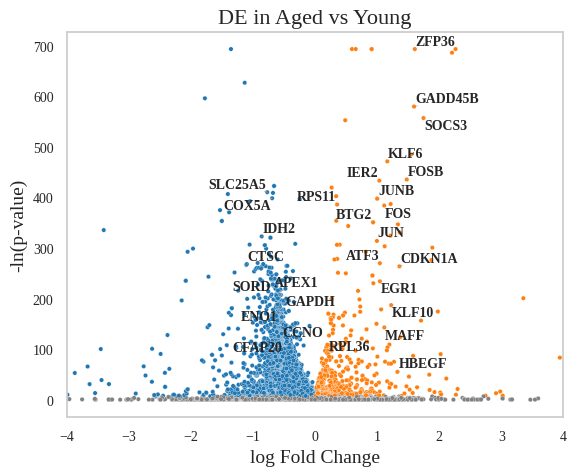

In [145]:
df = DEGs_age.copy()
df = df[df.pvals_adj < 0.90]
volcano(df, title="DE in Aged vs Young", text_pval_cut = 100, xlim = 4, too_crowded = True, genes_of_interest = gene_ls_short, print_sig_genes = False,
        color_left = "tab:blue", color_right = 'tab:orange', log_method = 'natural')

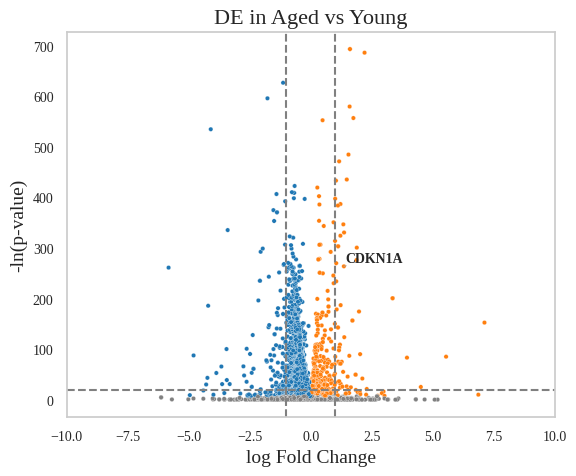

In [9]:
df = DEGs_age.copy()
df = df[df.pvals_adj < 0.90]
volcano(df, title="DE in Aged vs Young", text_pval_cut = 100, xlim = 10, too_crowded = True, genes_of_interest = ["CDKN1A"], print_sig_genes = False,
        color_left = "tab:blue", color_right = 'tab:orange', log_method = 'natural')
plt.axvline(1.0, color = 'grey', linestyle = '--')
plt.axvline(-1.0, color = 'grey', linestyle = '--')
plt.axhline(20, color = 'grey', linestyle = '--')

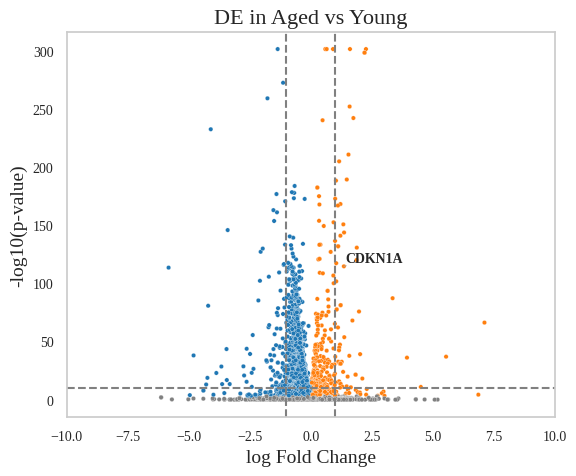

In [125]:
df = DEGs_age.copy()
df = df[df.pvals_adj < 0.90]
volcano(df, title="DE in Aged vs Young", text_pval_cut = 100, xlim = 10, too_crowded = True, genes_of_interest = ["CDKN1A"], print_sig_genes = False,
        color_left = "tab:blue", color_right = 'tab:orange', log_method = 'log10')
plt.axvline(1.0, color = 'grey', linestyle = '--')
plt.axvline(-1.0, color = 'grey', linestyle = '--')
plt.axhline(10, color = 'grey', linestyle = '--')

In [157]:
TF_list = list(set(pd.read_excel("drive/MyDrive/LU/Pavan_data/transcription factor list.xlsx", sheet_name=1)['Gene name'].to_list()))
print(len(TF_list))
TF_list = [i for i in TF_list if i in adata_full.var.index]
print(len(TF_list))

sc.tl.score_genes(adata_full, TF_list, ctrl_size = 5000, ctrl_as_ref = False, score_name = 'All_TFs_score', random_state = 0) # Calculate score for all TFs

adata_full.obs['All_TFs_score_normalized'] = (adata_full.obs['All_TFs_score'] - adata_full.obs['All_TFs_score'].min()) / (adata_full.obs['All_TFs_score'].max() - adata_full.obs['All_TFs_score'].min()) # min-max normalization

1819
1600


Text(0.5, 1.0, 'aged')

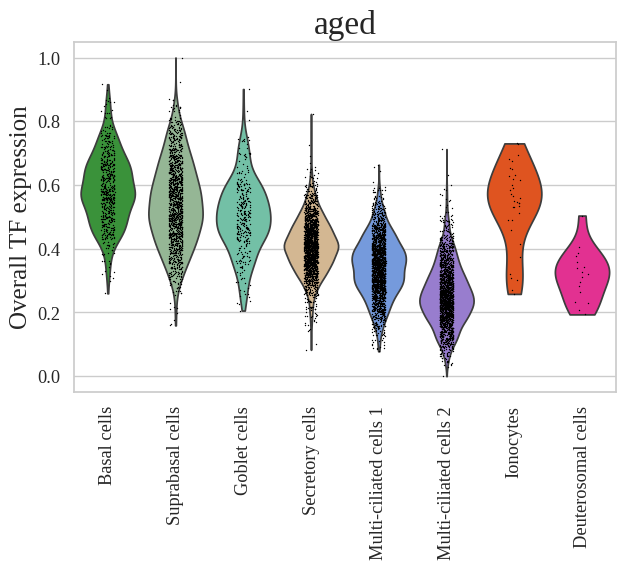

In [158]:
age_group = 'aged'
sc.pl.violin(adata_full[adata_full.obs['age_group'] == age_group], keys=["All_TFs_score_normalized",], groupby="anno_l3",
             order = ['Basal cells', "Suprabasal cells", "Goblet cells", "Secretory cells",  "Multi-ciliated cells 1", "Multi-ciliated cells 2", "Ionocytes", 'Deuterosomal cells'], rotation=90, show = False)
plt.ylabel('Overall TF expression', fontsize = 18)
# plt.ylim(-0.03, 1.03)
plt.title(age_group, fontsize = 24)

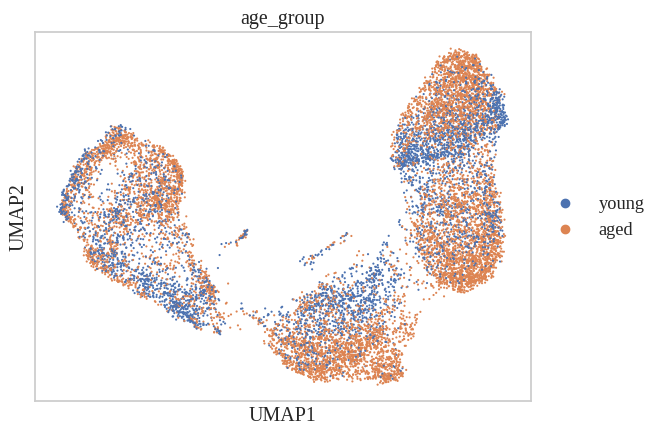

In [159]:
sc.pl.umap(adata_full, color = 'age_group')

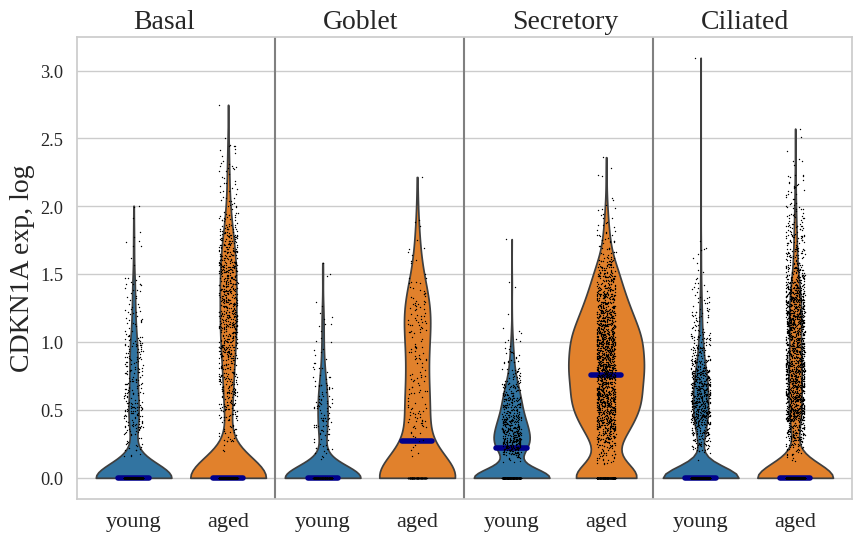

In [160]:
anno_col = 'anno_l1'

adata_full.obs['violin_col'] = adata_full.obs[anno_col].astype("string") + " " + adata_full.obs['age_group'].astype('string')
adata_full.obs['violin_col'] = adata_full.obs['violin_col'].astype("category")

for gene in ["CDKN1A"]:

  cell_ls = ["Basal cells", 'Goblet cells', 'Secretory cells', "Ciliated cells"]
  adata_subset = adata_full[(adata_full.obs[anno_col].isin(cell_ls))]
  # print(set(adata_subset.obs['violin_col']))
  condition_ls = ['young', 'aged']
  order = [f"{cell} {condition}" for cell in cell_ls for condition in condition_ls]
  colors = {"young" : "tab:blue", "aged" : "tab:orange"}
  color_dict = {f"{cell} {condition}": colors[condition] for cell in cell_ls for condition in condition_ls}

  fig, ax = plt.subplots(figsize = (10, 6)) #, facecolor = (1, 1, 1, 0)
  violin = sc.pl.violin(adata_subset, keys = gene, groupby = "violin_col", ax = ax, show = False, order = order, palette = color_dict)
  ax.tick_params(axis='x', rotation=0, labelsize = 16)
  ax.set_xlabel(""); ax.set_ylabel(gene + " exp, log", fontsize = 20);

  tick_labels = [i.split(" ")[2] for i in order]
  _ = ax.set_xticks(ticks = [i for i in range(len(tick_labels))],  labels = tick_labels)

  names_ls = [i.split(" ")[0] for i in order][::2]
  y_top = ax.get_ylim()[1] * 1.05 # Get top of the plot to know where to put names of Groups
  for pos in range(4):
    if pos>0:
      _ = ax.axvline(x=pos*2-0.5, c='grey') # Put grey lines between cell types
    _ =ax.text(pos*2, y_top - 0.1, names_ls[pos], fontsize = 20) # Put cell types above the violins

  for item in violin.get_children():
    if str(type(item)) == "<class 'matplotlib.collections.PathCollection'>":
      mean = item.get_offsets()[:,1].mean()

      median = np.median(item.get_offsets()[:,1])
      pos = item.get_offsets()[:,0].mean()
      ax.plot([pos-0.16,pos+0.16], [median, median], c='darkblue', linewidth = 4)
  ax.set_xlim(-0.6, 7.6)

  del adata_subset

In [19]:
tfs = pd.read_excel("drive/MyDrive/LU/Pavan_data/TF_programs.xlsx")
tfs[:3]

,Basal,Basal_Suprabasal,Suprabasal,Goblet,Secretory,Ciliated,Goblet_Secretory_Ciliated,Suprabasal_Goblet_Secretory_Ciliated,Suprabasal_Goblet_Secretory,Goblet_Secretory,Basal_Suprabasal_Goblet_Secretory,Secretory_Ciliated,General_all
0,TP63,HLF,ATF3,TET2,TARDBP,PHTF1,FUBP1,ELF3,HES4,ZNF593,UBTF,CENPS,RUNX1
1,ASCL2,IFI16,HES1,SOX4,ARID1A,ZC3H6,PBRM1,KDM5B,BHLHE40,ZNF326,CENPX,CASZ1,MBD2
2,ZFP36L2,ENO1,EGR1,AHR,PBX1,TMF1,PLSCR1,IRF1,KLF4,MIER1,ATF4,BOLA3,NCOR1


In [20]:
sc.pp.filter_genes(adata_full, min_cells = 30)

cell_type_TF_dict = {cell_type: tfs[cell_type].dropna().to_list() for cell_type in tfs.columns}

for cell_type in cell_type_TF_dict.keys():
  print(cell_type)
  ls = cell_type_TF_dict[cell_type]
  sc.tl.score_genes(adata_full, ls, ctrl_size = 2000, score_name = cell_type + '_score')

Basal
Basal_Suprabasal
Suprabasal
Goblet
Secretory
Ciliated
Goblet_Secretory_Ciliated
Suprabasal_Goblet_Secretory_Ciliated
Suprabasal_Goblet_Secretory
Goblet_Secretory
Basal_Suprabasal_Goblet_Secretory
Secretory_Ciliated
General_all


In [22]:
subset = adata_full[adata_full.obs['anno_l2'].isin(['Basal cells', 'Suprabasal cells', 'Goblet cells', 'Secretory cells', 'Ciliated cells'])].copy()
df = pd.DataFrame()
df['Pseudotime'] = subset.obs['dpt_pseudotime']
df['age_group'] = subset.obs['age_group']
for cell_type in cell_type_TF_dict.keys():
  df[cell_type + '_score'] = subset.obs[cell_type + '_score']
df = df.sort_values('Pseudotime')
del subset

df_normalized = df.drop(columns = ['age_group', 'Pseudotime'])
df_normalized = (df_normalized - df_normalized.min()) / (df_normalized.max() - df_normalized.min()) # min-max normalization
df_normalized.columns = df_normalized.columns.str.replace('_', ' ')
df_normalized['Pseudotime'] = df['Pseudotime']
df_normalized['age_group'] = df['age_group']

df_normalized[:2]

,Basal score,Basal Suprabasal score,Suprabasal score,Goblet score,Secretory score,Ciliated score,Goblet Secretory Ciliated score,Suprabasal Goblet Secretory Ciliated score,Suprabasal Goblet Secretory score,Goblet Secretory score,Basal Suprabasal Goblet Secretory score,Secretory Ciliated score,General all score,Pseudotime,age_group
barcodes,,,,,,,,,,,,,,,
GAGAGGTAGTCTAGAA-1,0.778963,0.588456,0.474531,0.465521,0.058820,0.207504,0.332247,0.192533,0.273660,0.401926,0.434412,0.299883,0.475180,0.000000,young
CAAGCTATCAGCGCAC-1-0,0.568893,0.573846,0.435994,0.246399,0.346005,0.308528,0.315253,0.354199,0.160995,0.480325,0.504824,0.344666,0.568784,0.003275,aged


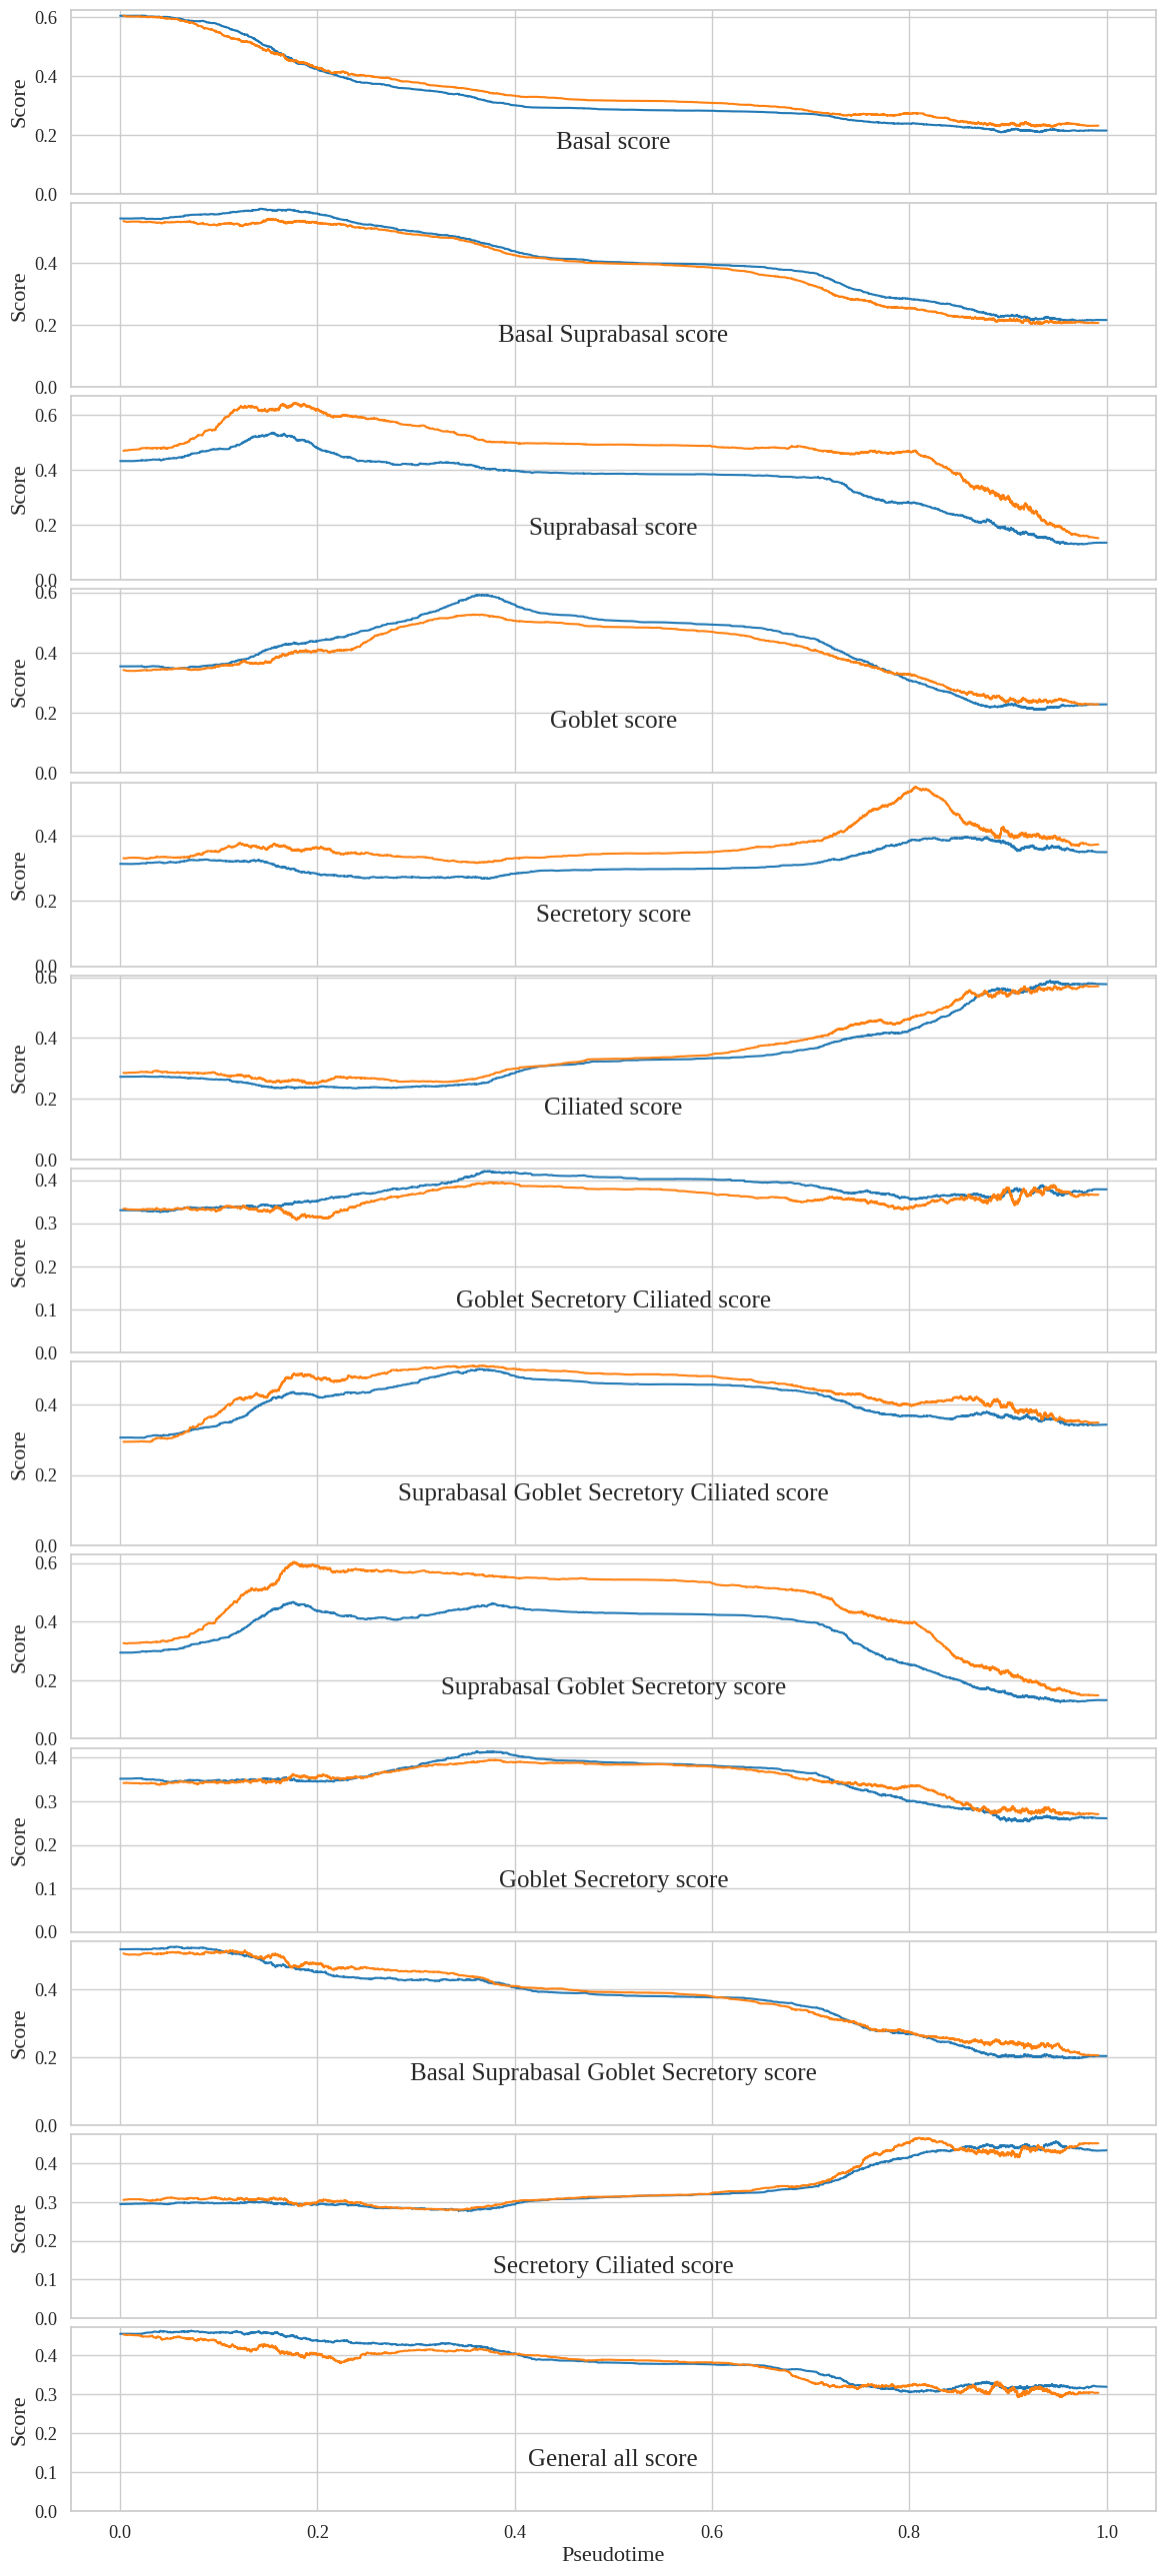

In [23]:
colors = {'aged': "tab:orange", "young": "tab:blue"}

fig, axes = plt.subplots(nrows=len(df_normalized.columns) - 2, ncols=1, figsize=(14, 2.5 * (len(df_normalized.columns) - 2)), sharex=True)
plt.subplots_adjust(hspace=0.05)  # Remove space between subplots

# Fix one subplot case
if len(df_normalized.columns) - 2 == 1:
    axes = [axes]

for idx, score in enumerate(df_normalized.columns):
    if score in ['Pseudotime', 'age_group']:
        continue

    data = df_normalized[[score, 'age_group', 'Pseudotime']]
    ax = axes[idx]  # Correct index shift

    for age_group in ['young', 'aged']:
        data_subset = data[data.age_group == age_group]
        ax.plot(data_subset['Pseudotime'],
                data_subset[score].rolling(300, min_periods=1, center = True).mean(),
                label=age_group, color=colors[age_group])
    ax.set_ylabel('Score', fontsize=16)
    bottom, top = ax.get_ylim()
    ax.set_ylim(0, top )

    if idx == len(axes) - 1:  # Only show x-axis label on the last subplot
        ax.set_xlabel("Pseudotime", fontsize=16)

    ax.set_title(score, fontsize=18, y = 0.2)
    ax.legend().remove()

### Versions

In [17]:
!python --version

Python 3.11.13


In [18]:
!pip list

Package                               Version
------------------------------------- -------------------
absl-py                               1.4.0
accelerate                            1.7.0
adjustText                            0.8
aiofiles                              24.1.0
aiohappyeyeballs                      2.6.1
aiohttp                               3.11.15
aiosignal                             1.3.2
alabaster                             1.0.0
albucore                              0.0.24
albumentations                        2.0.8
ale-py                                0.11.1
altair                                5.5.0
anndata                               0.11.4
annotated-types                       0.7.0
annoy                                 1.17.3
antlr4-python3-runtime                4.9.3
anyio                                 4.9.0
argon2-cffi                           23.1.0
argon2-cffi-bindings                  21.2.0
array-api-compat                      1.12.0
array_re